In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

$$a_j = \frac{e^{z_j}}{\sum_{k=1}^N e^{z_k}}$$


$$
L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases}
$$


$$
J(\mathbf{w},b) = -\frac{1}{m} \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right]
$$


In [2]:
def softmax(z):
  ez = np.exp(z)
  sm = ez / np.sum(ez)
  return sm

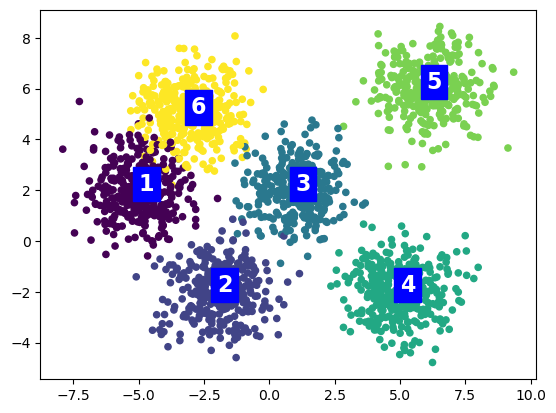

In [3]:
centers = np.array([[-5, 2], [-2, -2], [1, 2], [5, -2], [6, 6], [-3, 5]])
X_train, y_train, *_ = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
for i in range(len(centers)):
  plt.text(centers[i, 0], centers[i, 1], s=str(i+1), 
           fontsize=16, c='w', fontweight='bold', backgroundcolor='blue')
plt.show()

In [4]:
model = tf.keras.Sequential([
  tf.keras.layers.Dense(units=25, activation='relu'),
  tf.keras.layers.Dense(units=15, activation='relu'),
  tf.keras.layers.Dense(units=6, activation='softmax'),
])

model.compile(
  loss=tf.keras.losses.SparseCategoricalCrossentropy(),
  optimizer=tf.keras.optimizers.Adam(.001),
)

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 1.9037 
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step - loss: 0.8452
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 0.4742
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 0.3117
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.2296
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.1789
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 0.1450
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - loss: 0.1209
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.1038
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.0909
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - loss: 0.0813
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 0.0734
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - loss: 0.0703
Epoch 14/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - loss: 0.0641
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s

In [5]:
X = np.array([[2.5, 4]])
p = np.argmax(model.predict(X)) + 1
print(f"Prediction for {X}:", p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction for [[2.5 4. ]]: 3


In [6]:
# Recommended Usage: (set from_logits=True)
# https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy

preferred_model = tf.keras.Sequential([
  tf.keras.layers.Dense(units=25, activation='relu'),
  tf.keras.layers.Dense(units=15, activation='relu'),
  tf.keras.layers.Dense(units=6, activation='linear'),
])

preferred_model.compile(
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  optimizer=tf.keras.optimizers.Adam(.001),
)

preferred_model.fit(
  X_train, y_train,
  epochs=100
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - loss: 1.1566 
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 0.6436
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.4027
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2903
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - loss: 0.2228
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.1755
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - loss: 0.1425
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.1170
Epoch 9/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.0990
Epoch 10/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 0.0869
Epoch 11/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - loss: 0.0781
Epoch 12/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 0.0712
Epoch 13/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 0.0663
Epoch 14/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.0611
Epoch 15/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6

In [7]:
p_preferred = preferred_model.predict(X)
sm_preferred = tf.nn.softmax(p_preferred)
p_2 = np.argmax(sm_preferred) + 1
print(f"Prediction for {X}:", p_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction for [[2.5 4. ]]: 3
